## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

practice_dir_path = '/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/03 Discords'
os.chdir(practice_dir_path)

In [3]:
!pwd

/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/03 Discords


В данной будет использоваться временной ряд, состоящий из показаний акселерометра.
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [4]:
!pip install scipy
!pip install scikit-learn

In [72]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [73]:
#fixme: Путь
dataset_dir_path = Path(f'{practice_dir_path}/datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

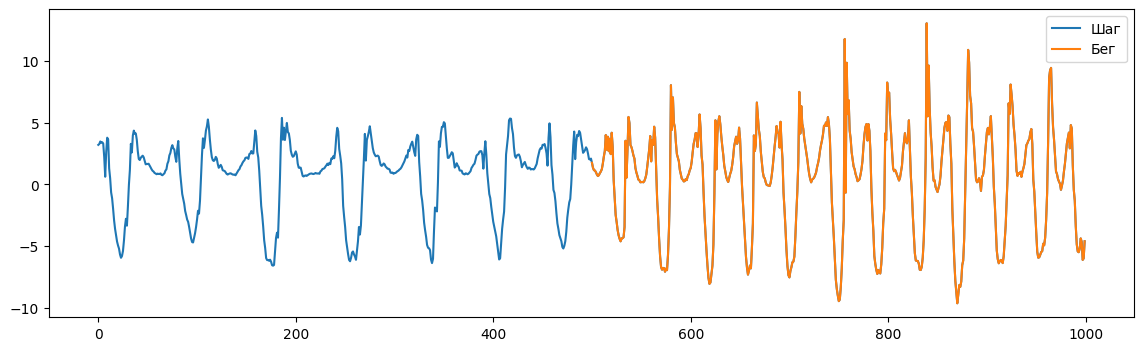

In [74]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [ ]:
#result={}
#times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [76]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 10))
end = time()

print(end - start)
discords_brute_force

255.91626811027527


array([[477.        ,   5.88100934],
       [412.        ,   5.32704317],
       [195.        ,   3.39426635],
       [577.        ,   3.35554403],
       [278.        ,   3.10959389],
       [755.        ,   3.10876544],
       [ 34.        ,   3.08283408],
       [346.        ,   3.08283408],
       [113.        ,   2.99463564],
       [660.        ,   2.9792707 ]])

##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [ ]:
# INSERT YOUR CODE

In [77]:
from modules.saxpy.hotsax import find_discords_hotsax


start = time()
discords_hotsax = find_discords_hotsax(data[:], num_discords=10, win_size=size_sub)
end = time()

print(end - start, '\n')
discords_hotsax

4.6997857093811035 



[(477, np.float64(5.881009341683914)),
 (412, np.float64(5.327043167878002)),
 (195, np.float64(3.3942663473023327)),
 (577, np.float64(3.3555440274836608)),
 (278, np.float64(3.10959388763498)),
 (755, np.float64(3.1087654444834554)),
 (34, np.float64(3.0828340814500437)),
 (346, np.float64(3.0828340814500437)),
 (113, np.float64(2.994635643430992)),
 (660, np.float64(2.97927069628054))]

##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

In [ ]:
# INSERT YOUR CODE

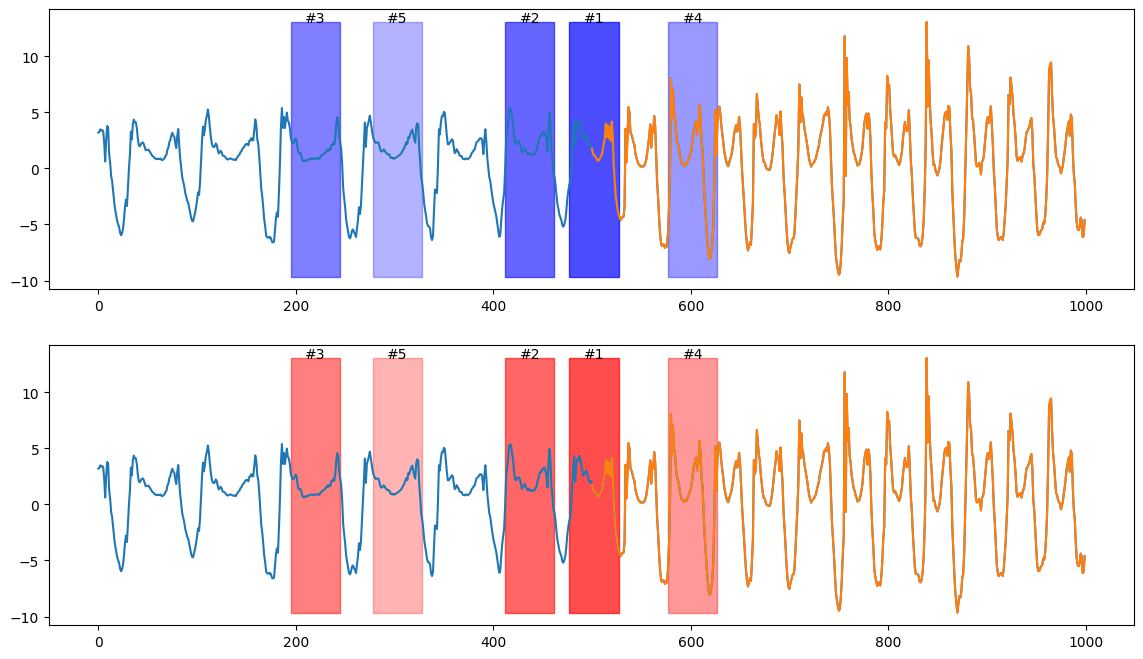

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.label = 'brute force'
ax2.label = 'hotsax'
mn, mx = min(data), max(data)

for i in range(len(discords_brute_force)):
    alpha = 1-(i+3)*0.1
    ax1.add_patch(Rectangle(xy=(discords_brute_force[i][0], mn), width=size_sub, height=mx-mn, color='blue', alpha=alpha))
    ax1.text(discords_brute_force[i][0]+size_sub/2, mx, f"#{i+1}", ha='center')
ax1.plot(data[:], label='Шаг')
ax1.plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Бег')

for i in range(len(discords_hotsax)):
    alpha = 1-(i+3)*0.1
    ax2.add_patch(Rectangle(xy=(discords_hotsax[i][0], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
    ax2.text(discords_hotsax[i][0]+size_sub/2, mx, f"#{i+1}", ha='center')
ax2.plot(data[:], label='Шаг')
ax2.plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Бег')

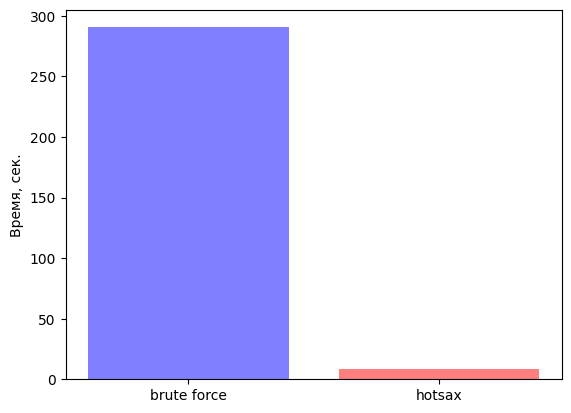

In [ ]:
fig, ax = plt.subplots()
ax.bar(['brute force', 'hotsax'], [290.58384823799133, 8.51403546333313], color=['blue', 'red'], alpha=0.5)
ax.set_ylabel('Время, сек.');

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами.

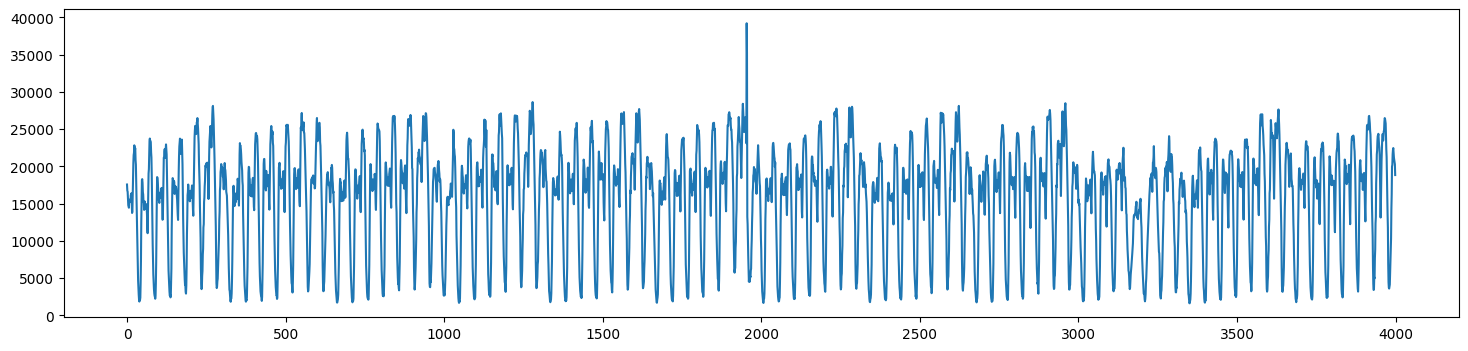

In [7]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

# INSERT YOUR CODE

In [ ]:
discords_brute_force = find_discords_brute_force(nyc_taxi[:], win_size=size_sub, num_discords=1) #

In [ ]:
discords_hotsax = find_discords_hotsax(nyc_taxi[:], num_discords=5, win_size=size_sub)

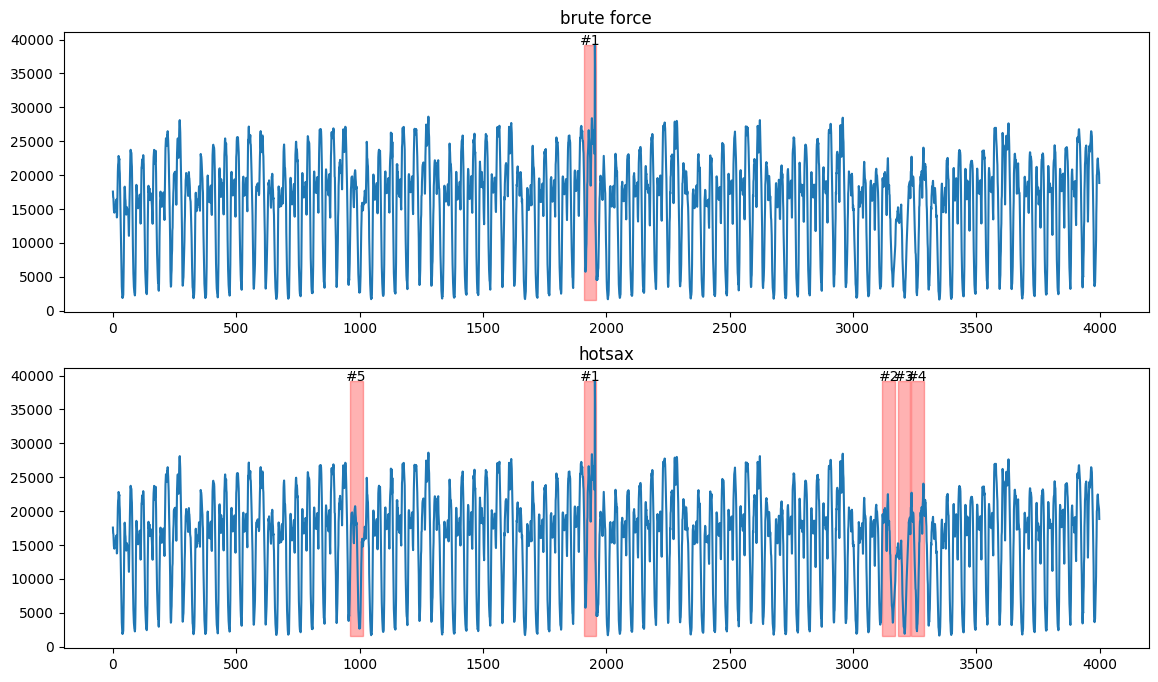

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.set_title('brute force')
ax2.set_title('hotsax')
mn, mx = min(nyc_taxi), max(nyc_taxi)

for i in range(len(discords_brute_force)):
    alpha = 0.3
    ax1.add_patch(Rectangle(xy=(discords_brute_force[i][0], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
    ax1.text(discords_brute_force[i][0]+size_sub/2, mx, f"#{i+1}", ha='center')
ax1.plot(nyc_taxi)

for i in range(len(discords_hotsax)):
    alpha = 0.3
    ax2.add_patch(Rectangle(xy=(discords_hotsax[i][0], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
    ax2.text(discords_hotsax[i][0]+size_sub/2, mx, f"#{i+1}", ha='center')
ax2.plot(nyc_taxi)

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [10]:
!pip install stumpy==1.11.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: stumpy
    Found existing installation: stumpy 1.13.0
    Uninstalling stumpy-1.13.0:
      Successfully uninstalled stumpy-1.13.0


In [11]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump

stumpy.config.STUMPY_EXCL_GPU = True


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога.

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [12]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [ ]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [ ]:
m = 50
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат.

In [ ]:
m = 50
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

In [ ]:
# INSERT YOUR CODE

In [ ]:
m = 50
r = 10
idxs_r_10, _, _ = DRAG(nyc_taxi, m, r)
print(f'Колличество найденных диссонансов: {len(idxs_r_10)}')

Колличество найденных диссонансов: 0


In [ ]:
m = 50
r = 1
idxs_r_1, _, _ = DRAG(nyc_taxi, m, r)
print(f'Колличество найденных диссонансов: {len(idxs_r_1)}')

Колличество найденных диссонансов: 42


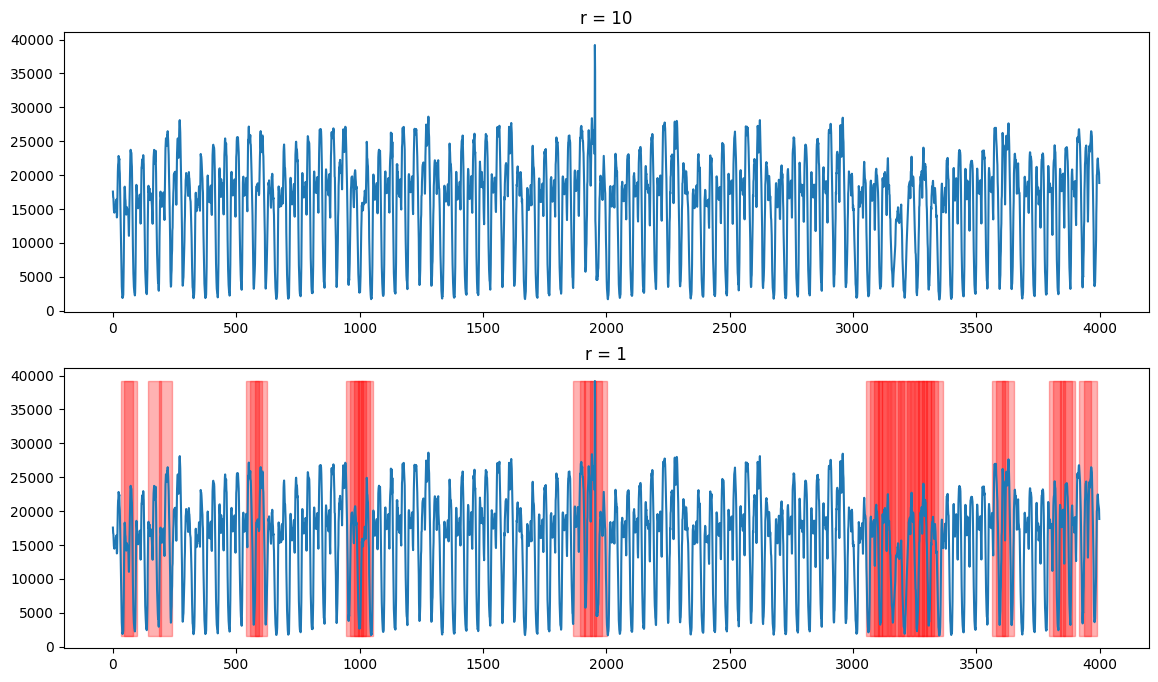

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.set_title('r = 10')
ax2.set_title('r = 1')
mn, mx = min(nyc_taxi), max(nyc_taxi)

for i in range(len(idxs_r_10)):
    alpha = 0.3
    ax1.add_patch(Rectangle(xy=(idxs_r_10[i], mn), width=size_sub, height=mx-mn, color='blue', alpha=alpha))
ax1.plot(nyc_taxi)

for i in range(len(idxs_r_1)):
    alpha = 0.3
    ax2.add_patch(Rectangle(xy=(idxs_r_1[i], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
ax2.plot(nyc_taxi)

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [ ]:
#выбирем более реальное значение для порога
r = 3

In [ ]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1,
#элемент массива является истинным,
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [ ]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности.
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

In [ ]:
# INSERT YOUR CODE

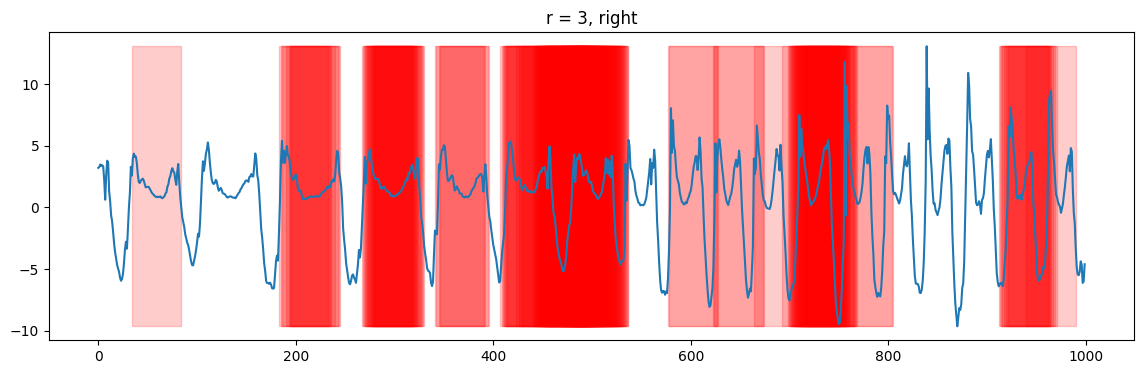

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title('r = 3, right')
mn, mx = min(data), max(data)

for i in range(len(cand_index)):
    alpha = 0.2
    ax.add_patch(Rectangle(xy=(cand_index[i], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
ax.plot(data)

Сделайте вывод о том, как эти параметры влияют на качество работы модели.

**Значение m влияет на то, какие диссонансы ищутся, а значение r влияет на количество (т.е. на качество) найденных диссонансов**

Подберите оптимальные параметры алгоритма для набора данных такси NY.

In [ ]:
m_vals = [30, 35, 40, 45, 50, 55, 60]
r_vals = [2.5, 3, 3.5]

idxs = []
dists = []
nn_idxs = []

for m in m_vals:
    for r in r_vals:
        T, M_T, Σ_T = core.preprocess(nyc_taxi, m)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
        discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)

        idxs.append(discords_idx)
        dists.append(discords_dist)
        nn_idxs.append(discords_nn_idx)

        print(f'Done: m={m}, r={r}')

Done: m=30, r=2.5
Done: m=30, r=3
Done: m=30, r=3.5
Done: m=35, r=2.5
Done: m=35, r=3
Done: m=35, r=3.5
Done: m=40, r=2.5
Done: m=40, r=3
Done: m=40, r=3.5
Done: m=45, r=2.5
Done: m=45, r=3
Done: m=45, r=3.5
Done: m=50, r=2.5
Done: m=50, r=3
Done: m=50, r=3.5
Done: m=55, r=2.5
Done: m=55, r=3
Done: m=55, r=3.5
Done: m=60, r=2.5
Done: m=60, r=3
Done: m=60, r=3.5


Визуализируйте результаты для разных комбинаций. Сделайте выводы.

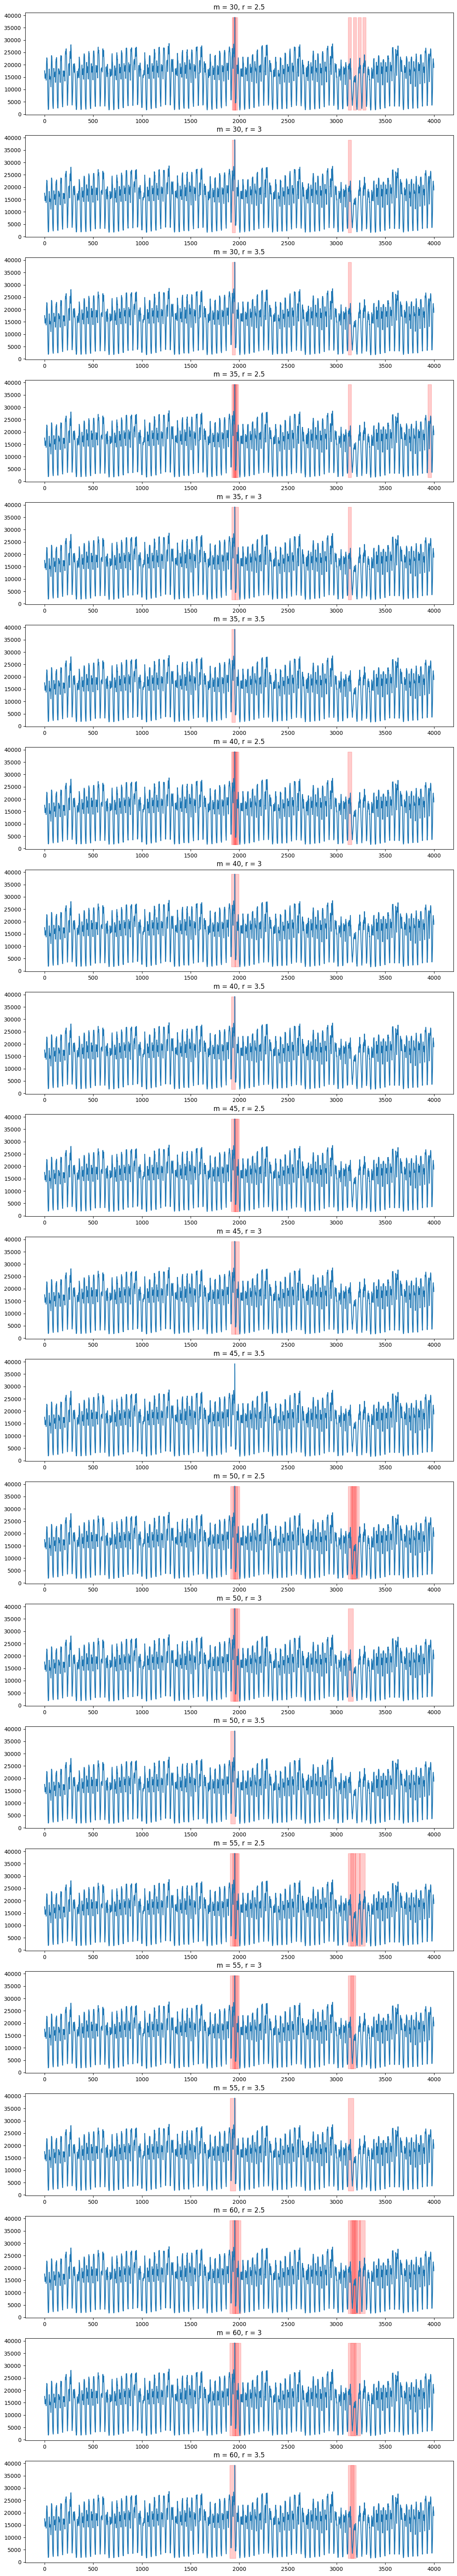

In [ ]:
n = len(m_vals)*len(r_vals)
mn, mx = min(nyc_taxi), max(nyc_taxi)
fig, axs = plt.subplots(n, 1, figsize=(14, 4*n))

for j in range(n):
    axs[j].set_title(f'm = {m_vals[j//len(r_vals)]}, r = {r_vals[j%len(r_vals)]}')

    for i in range(len(idxs[j])):
        alpha = 0.2
        axs[j].add_patch(Rectangle(xy=(idxs[j][i], mn), width=m_vals[j//len(r_vals)], height=mx-mn, color='red', alpha=alpha))
    axs[j].plot(nyc_taxi)

# e.g. 30, 3

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [ ]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [ ]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

In [ ]:
# INSERT YOUR CODE

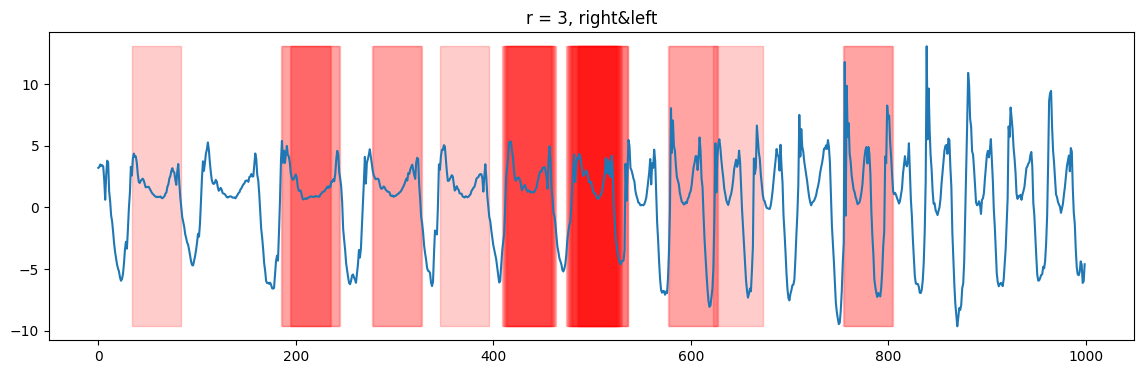

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title('r = 3, right&left')
mn, mx = min(data), max(data)

for i in range(len(cands)):
    alpha = 0.2
    ax.add_patch(Rectangle(xy=(cands[i], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
ax.plot(data)

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [ ]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

In [ ]:
# INSERT YOUR CODE

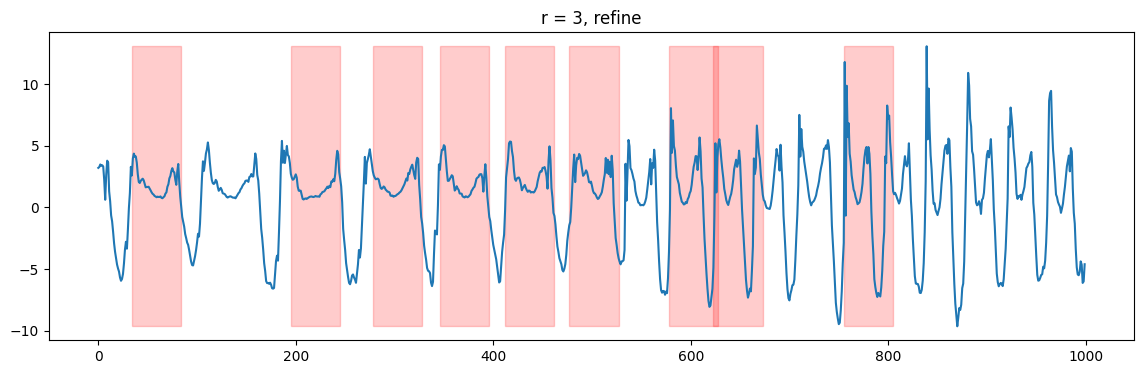

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title('r = 3, refine')
mn, mx = min(data), max(data)

for i in range(len(discords_idx)):
    alpha = 0.2
    ax.add_patch(Rectangle(xy=(discords_idx[i], mn), width=size_sub, height=mx-mn, color='red', alpha=alpha))
ax.plot(data)

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY.
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


In [ ]:
# INSERT YOUR CODE

In [ ]:
m_vals = [30, 35, 40, 45, 50, 55, 60]
r_vals = [2.5, 3, 3.5]

idxs = []
dists = []
nn_idxs = []

for m in m_vals:
    for r in r_vals:
        T, M_T, Σ_T = core.preprocess(data, m)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
        discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)

        idxs.append(discords_idx)
        dists.append(discords_dist)
        nn_idxs.append(discords_nn_idx)

        print(f'Done: m={m}, r={r}')

Done: m=30, r=2.5
Done: m=30, r=3
Done: m=30, r=3.5
Done: m=35, r=2.5
Done: m=35, r=3
Done: m=35, r=3.5
Done: m=40, r=2.5
Done: m=40, r=3
Done: m=40, r=3.5
Done: m=45, r=2.5
Done: m=45, r=3
Done: m=45, r=3.5
Done: m=50, r=2.5
Done: m=50, r=3
Done: m=50, r=3.5
Done: m=55, r=2.5
Done: m=55, r=3
Done: m=55, r=3.5
Done: m=60, r=2.5
Done: m=60, r=3
Done: m=60, r=3.5


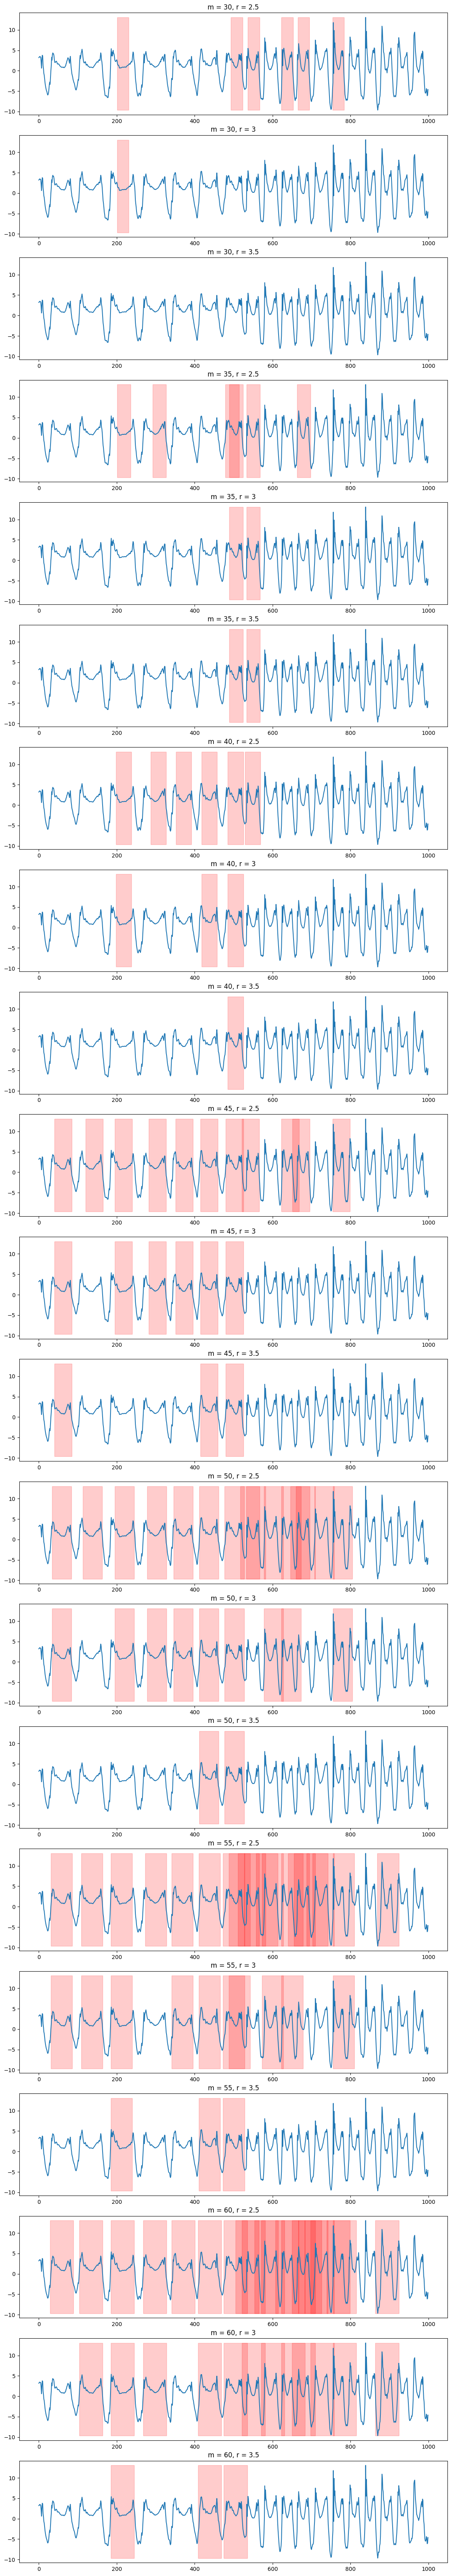

In [ ]:
n = len(m_vals)*len(r_vals)
mn, mx = min(data), max(data)
fig, axs = plt.subplots(n, 1, figsize=(14, 4*n))

for j in range(n):
    axs[j].set_title(f'm = {m_vals[j//len(r_vals)]}, r = {r_vals[j%len(r_vals)]}')

    for i in range(len(idxs[j])):
        alpha = 0.2
        axs[j].add_patch(Rectangle(xy=(idxs[j][i], mn), width=m_vals[j//len(r_vals)], height=mx-mn, color='red', alpha=alpha))
    axs[j].plot(data)

# 35, 3

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов.

In [46]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса,
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [47]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [48]:
maxL

55

In [49]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых.
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы.

![merlin-part-first](pics/second_part.png)


In [50]:
# INSERT YOUR CODE
import time

max_no_progress = 3
no_progress = 0
iteration = 0

print("Второй этап - поиск диссонансов по длинам\n")

while cound_find_dis < topK and cound_find_dis > 0 and no_progress < max_no_progress:
    iteration+=1
    prev_count = cound_find_dis

    prev_nnDist = dis_nnDist[cound_find_dis - 1]
    r = 0.99 * prev_nnDist
    minL = m + 1
    maxL = m + 5

    for current_m in range(minL, maxL + 1):
        start_time = time.time()
        result = DRAG(data=T, m=current_m, r=r, include=include)
        elapsed = time.time() - start_time

        diss_candidates = len(result[0])
        print(f"Итерация {iteration}: m={current_m}, r={r:.3f}, найдено {diss_candidates} кандидатов за {elapsed:.2f} сек")

        for diss, nnDist, nn in zip(*result):
            if cound_find_dis >= topK:
                break

            zone = np.arrange(diss, diss + current_m)
            overlap_ratio = np.mean(~include[zone])

            if overlap_ratio <= 0.25:
                dis_idx[cound_find_dis] = diss
                dis_nnDist[cound_find_dis] = nnDist
                dis_nn_idx[cound_find_dis] = nn
                core.apply_exclusion_zone(include, diss, excl_zone, False)

    if cound_find_dis == prev_count:
        no_progress += 1
    else:
        no_progress = 0

    if cound_find_dis >= topK:
        break

print(f"\nДиссонансы после второго шага: {cound_find_dis}")
if no_progress >= max_no_progress:
    print("")

Второй этап - поиск диссонансов по длинам

Итерация 1: m=51, r=5.274, найдено 0 кандидатов за 0.23 сек
Итерация 1: m=52, r=5.274, найдено 0 кандидатов за 0.24 сек
Итерация 1: m=53, r=5.274, найдено 0 кандидатов за 0.20 сек
Итерация 1: m=54, r=5.274, найдено 0 кандидатов за 0.23 сек
Итерация 1: m=55, r=5.274, найдено 0 кандидатов за 0.28 сек
Итерация 2: m=51, r=5.274, найдено 0 кандидатов за 0.23 сек
Итерация 2: m=52, r=5.274, найдено 0 кандидатов за 0.24 сек
Итерация 2: m=53, r=5.274, найдено 0 кандидатов за 0.21 сек
Итерация 2: m=54, r=5.274, найдено 0 кандидатов за 0.23 сек
Итерация 2: m=55, r=5.274, найдено 0 кандидатов за 0.25 сек
Итерация 3: m=51, r=5.274, найдено 0 кандидатов за 0.23 сек
Итерация 3: m=52, r=5.274, найдено 0 кандидатов за 0.23 сек
Итерация 3: m=53, r=5.274, найдено 0 кандидатов за 0.19 сек
Итерация 3: m=54, r=5.274, найдено 0 кандидатов за 0.22 сек
Итерация 3: m=55, r=5.274, найдено 0 кандидатов за 0.26 сек

Диссонансы после второго шага: 2



Третий этап - поиск оставшихся диссонансов

Итерация 1, стартовое r = 5.0501
m=50.00, найдено 0 (r=5.050) за 5.42 сек
m=51.00, найдено 0 (r=4.949) за 5.66 сек
m=52.00, найдено 0 (r=4.850) за 5.93 сек
m=53.00, найдено 0 (r=4.753) за 6.24 сек
m=54.00, найдено 0 (r=4.658) за 6.52 сек
m=55.00, найдено 0 (r=4.565) за 6.84 сек
m=56.00, найдено 0 (r=4.474) за 7.15 сек
m=57.00, найдено 0 (r=4.384) за 7.46 сек
m=58.00, найдено 1 (r=4.296) за 7.75 сек
m=59.00, найдено 1 (r=5.327) за 7.95 сек
m=60.00, найдено 1 (r=5.327) за 8.18 сек
m=61.00, найдено 1 (r=5.327) за 8.41 сек
m=62.00, найдено 1 (r=5.327) за 8.67 сек
m=63.00, найдено 1 (r=5.327) за 8.94 сек
m=64.00, найдено 1 (r=5.327) за 9.25 сек
m=65.00, найдено 1 (r=5.327) за 9.52 сек
m=66.00, найдено 1 (r=5.327) за 9.79 сек
m=67.00, найдено 1 (r=5.327) за 10.03 сек
m=68.00, найдено 1 (r=5.327) за 10.30 сек
m=69.00, найдено 1 (r=5.327) за 10.56 сек
m=70.00, найдено 1 (r=5.327) за 10.80 сек
m=71.00, найдено 1 (r=5.327) за 11.03 сек
m=72.00, найдено

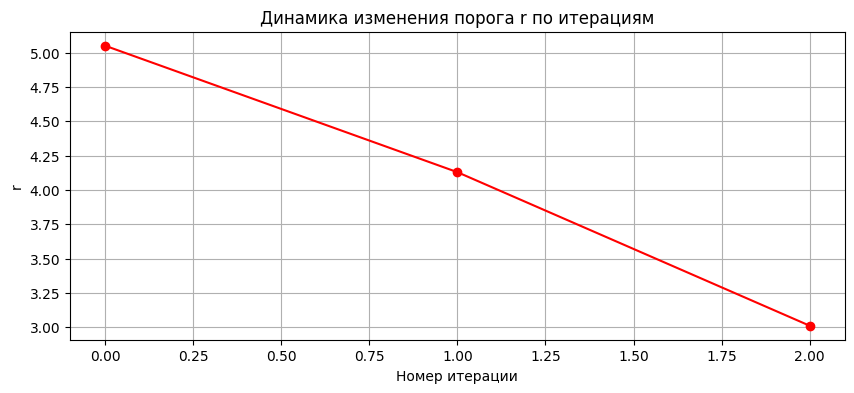

In [51]:
import numpy as np
import time
import matplotlib.pyplot as plt
from stumpy import core
from modules.drag import DRAG

found_before_step3 = cound_find_dis
print("Третий этап - поиск оставшихся диссонансов\n")

max_iters = 30
iter_count = 0
start_total = time.time()

length_range = range(m, m + 25)
r_history = []

while cound_find_dis < topK and iter_count < max_iters:
    iter_count += 1

    if np.any(dis_nnDist[:cound_find_dis] > 0):
        recent_nn = dis_nnDist[max(0, cound_find_dis - 5):cound_find_dis]
        mu = np.mean(recent_nn)
        sigma = np.std(recent_nn)
        r = max(mu-2*sigma, 1e-3)
    else:
        r = 2 * np.sqrt(m)

    r_history.append(r)
    found_this_iter = 0

    print(f"Итерация {iter_count}, стартовое r = {r:.4f}")

    for current_m in length_range:
        start_tiem = time.time()
        result = DRAG(data=T, m=current_m, r=r, include=include)
        elapsed = time.time() - start_time

        for diss, nnDist, nn in zip(*result):
            if cound_find_dis >= topK:
                break

            zone = np.arange(diss, diss + current_m)
            overlap_ratio = np.mean(~include[zone])

            if overlap_ratio <= 0.25:
                dis_idx[cound_find_dis] = diss
                dis_nnDist[cound_find_dis] = nnDist
                dis_nn_idx[cound_find_dis] = nn
                core.apply_exclusion_zone(include, diss, excl_zone, False)
                cound_find_dis += 1
                found_this_iter += 1

        print(f"m={current_m:.02f}, найдено {found_this_iter} (r={r:.3f}) за {elapsed:.2f} сек")

        if found_this_iter == 0:
            r *= 0.98
        else:
            r = max(r, np.median(dis_nnDist[:cound_find_dis])) # стабилизация

    if found_this_iter == 0:
        r *=  0.9
        print(f"Нет прогресса, r уменьшено до {r:.4f}")

    if cound_find_dis >= topK:
        break

elapsed_total = time.time() - start_total
found_after_step3 = cound_find_dis - found_before_step3

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Найдено новых диссонансов: {found_after_step3}")
print(f"Всего найдено: {cound_find_dis}")
print(f"Индексы: {dis_idx[dis_idx >= 0].astype(int)}")
print(f"Общее время: {elapsed_total:.2f} сек")

plt.figure(figsize=(10,4))
plt.plot(r_history, marker='o', linestyle='-', color='red')
plt.title("Динамика изменения порога r по итерациям")
plt.xlabel("Номер итерации")
plt.ylabel("r")
plt.grid(True)
plt.show()

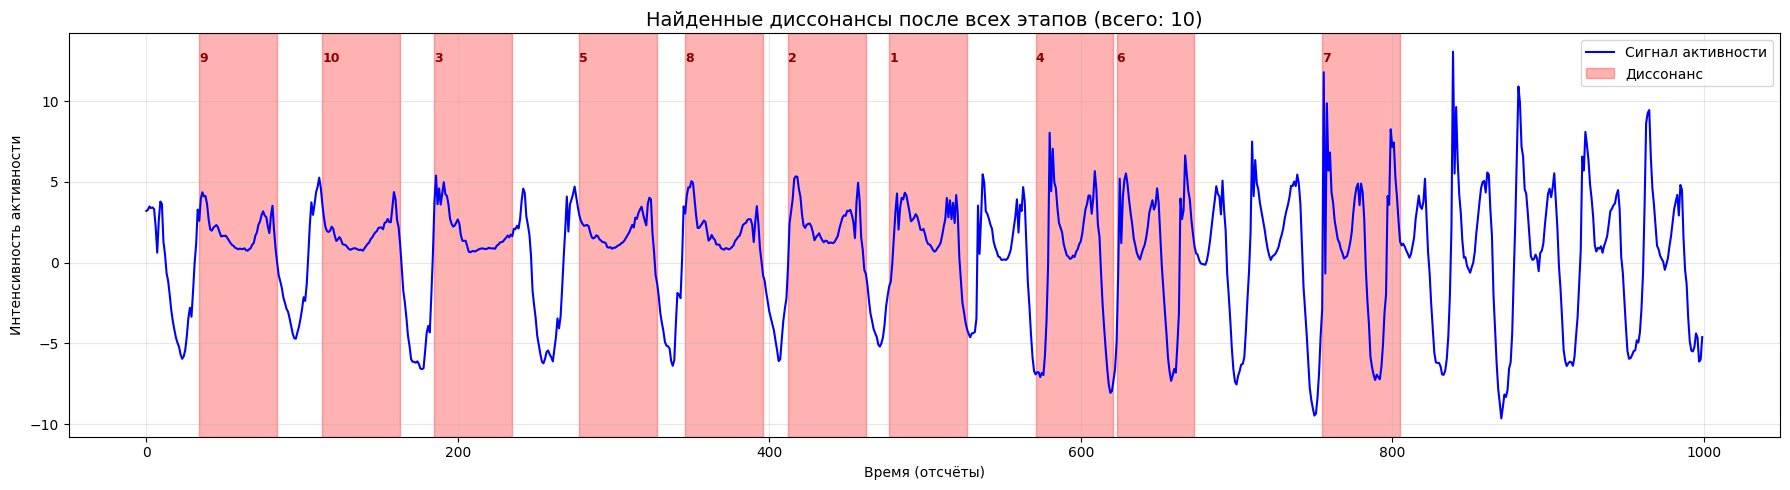

In [53]:
import matplotlib.pyplot as plt

valid_dis_idx = dis_idx[dis_idx >= 0].astype(int)

plt.figure(figsize=(18, 5))
plt.plot(T, color='blue', label='Сигнал активности')
for i, idx in enumerate(valid_dis_idx):
    plt.axvspan(idx, idx + m, color = 'red', alpha=0.3, label='Диссонанс' if i == 0 else None)
    plt.text(idx, np.max(T)*0.95, f'{i+1}', color='darkred', fontsize=9, fontweight='bold')

plt.title(f"Найденные диссонансы после всех этапов (всего: {len(valid_dis_idx)})", fontsize=14)
plt.xlabel("Время (отсчёты)")
plt.ylabel("Интенсивность активности")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов.


In [66]:
T = nyc_taxi
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса,
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 20

In [67]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [68]:
maxL

55

In [69]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 12


In [70]:
# INSERT YOUR CODE
import time

max_no_progress = 3
no_progress = 0
iteration = 0

print("Второй этап - поиск диссонансов по длинам\n")

while cound_find_dis < topK and cound_find_dis > 0 and no_progress < max_no_progress:
    iteration+=1
    prev_count = cound_find_dis

    prev_nnDist = dis_nnDist[cound_find_dis - 1]
    r = 0.99 * prev_nnDist
    minL = m + 1
    maxL = m + 5

    for current_m in range(minL, maxL + 1):
        start_time = time.time()
        result = DRAG(data=T, m=current_m, r=r, include=include)
        elapsed = time.time() - start_time

        diss_candidates = len(result[0])
        print(f"Итерация {iteration}: m={current_m}, r={r:.3f}, найдено {diss_candidates} кандидатов за {elapsed:.2f} сек")

        for diss, nnDist, nn in zip(*result):
            if cound_find_dis >= topK:
                break

            zone = np.arrange(diss, diss + current_m)
            overlap_ratio = np.mean(~include[zone])

            if overlap_ratio <= 0.25:
                dis_idx[cound_find_dis] = diss
                dis_nnDist[cound_find_dis] = nnDist
                dis_nn_idx[cound_find_dis] = nn
                core.apply_exclusion_zone(include, diss, excl_zone, False)

    if cound_find_dis == prev_count:
        no_progress += 1
    else:
        no_progress = 0

    if cound_find_dis >= topK:
        break

print(f"\nДиссонансы после второго шага: {cound_find_dis}")
if no_progress >= max_no_progress:
    print("")

Второй этап - поиск диссонансов по длинам

Итерация 1: m=51, r=1.751, найдено 0 кандидатов за 1.37 сек
Итерация 1: m=52, r=1.751, найдено 0 кандидатов за 1.41 сек
Итерация 1: m=53, r=1.751, найдено 0 кандидатов за 1.96 сек
Итерация 1: m=54, r=1.751, найдено 0 кандидатов за 2.32 сек
Итерация 1: m=55, r=1.751, найдено 0 кандидатов за 1.40 сек
Итерация 2: m=51, r=1.751, найдено 0 кандидатов за 1.37 сек
Итерация 2: m=52, r=1.751, найдено 0 кандидатов за 1.42 сек
Итерация 2: m=53, r=1.751, найдено 0 кандидатов за 1.41 сек
Итерация 2: m=54, r=1.751, найдено 0 кандидатов за 1.46 сек
Итерация 2: m=55, r=1.751, найдено 0 кандидатов за 1.36 сек
Итерация 3: m=51, r=1.751, найдено 0 кандидатов за 1.39 сек
Итерация 3: m=52, r=1.751, найдено 0 кандидатов за 2.14 сек
Итерация 3: m=53, r=1.751, найдено 0 кандидатов за 2.16 сек
Итерация 3: m=54, r=1.751, найдено 0 кандидатов за 1.40 сек
Итерация 3: m=55, r=1.751, найдено 0 кандидатов за 1.37 сек

Диссонансы после второго шага: 12



Третий этап - поиск оставшихся диссонансов

Итерация 1, стартовое r = 1.5579
m=50.00, найдено 1 (r=1.558) за 11.85 сек
m=51.00, найдено 1 (r=2.615) за 12.77 сек
m=52.00, найдено 1 (r=2.615) за 13.68 сек
m=53.00, найдено 1 (r=2.615) за 14.58 сек
m=54.00, найдено 1 (r=2.615) за 15.47 сек
m=55.00, найдено 1 (r=2.615) за 16.45 сек
m=56.00, найдено 1 (r=2.615) за 17.47 сек
m=57.00, найдено 1 (r=2.615) за 18.40 сек
m=58.00, найдено 1 (r=2.615) за 19.29 сек
m=59.00, найдено 1 (r=2.615) за 20.19 сек
m=60.00, найдено 1 (r=2.615) за 21.32 сек
m=61.00, найдено 1 (r=2.615) за 22.80 сек
m=62.00, найдено 1 (r=2.615) за 24.35 сек
m=63.00, найдено 1 (r=2.615) за 25.74 сек
m=64.00, найдено 1 (r=2.615) за 26.78 сек
m=65.00, найдено 1 (r=2.615) за 27.80 сек
m=66.00, найдено 1 (r=2.615) за 28.79 сек
m=67.00, найдено 1 (r=2.615) за 29.75 сек
m=68.00, найдено 1 (r=2.615) за 30.69 сек
m=69.00, найдено 1 (r=2.615) за 31.57 сек
m=70.00, найдено 1 (r=2.615) за 32.56 сек
m=71.00, найдено 1 (r=2.615) за 33.55 сек

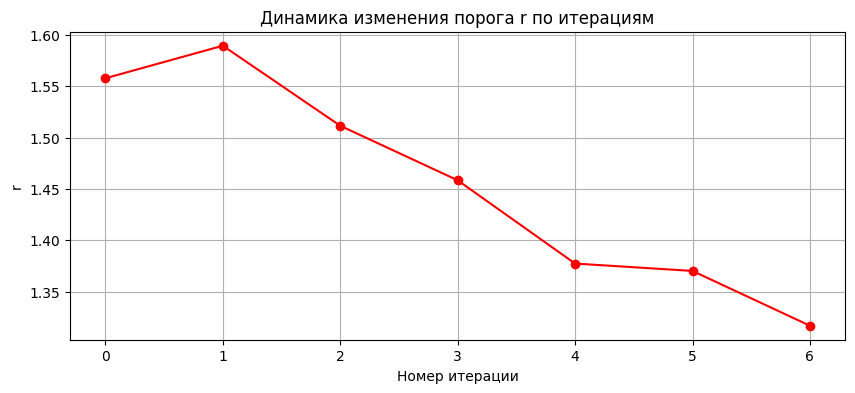

In [71]:
import numpy as np
import time
import matplotlib.pyplot as plt
from stumpy import core
from modules.drag import DRAG

found_before_step3 = cound_find_dis
print("Третий этап - поиск оставшихся диссонансов\n")

max_iters = 30
iter_count = 0
start_total = time.time()

length_range = range(m, m + 25)
r_history = []

while cound_find_dis < topK and iter_count < max_iters:
    iter_count += 1

    if np.any(dis_nnDist[:cound_find_dis] > 0):
        recent_nn = dis_nnDist[max(0, cound_find_dis - 5):cound_find_dis]
        mu = np.mean(recent_nn)
        sigma = np.std(recent_nn)
        r = max(mu-2*sigma, 1e-3)
    else:
        r = 2 * np.sqrt(m)

    r_history.append(r)
    found_this_iter = 0

    print(f"Итерация {iter_count}, стартовое r = {r:.4f}")

    for current_m in length_range:
        start_tiem = time.time()
        result = DRAG(data=T, m=current_m, r=r, include=include)
        elapsed = time.time() - start_time

        for diss, nnDist, nn in zip(*result):
            if cound_find_dis >= topK:
                break

            zone = np.arange(diss, min(diss + current_m, len(include)))
            overlap_ratio = np.mean(~include[zone])

            if overlap_ratio <= 0.25:
                dis_idx[cound_find_dis] = diss
                dis_nnDist[cound_find_dis] = nnDist
                dis_nn_idx[cound_find_dis] = nn
                core.apply_exclusion_zone(include, diss, excl_zone, False)
                cound_find_dis += 1
                found_this_iter += 1

        print(f"m={current_m:.02f}, найдено {found_this_iter} (r={r:.3f}) за {elapsed:.2f} сек")

        if found_this_iter == 0:
            r *= 0.98
        else:
            r = max(r, np.median(dis_nnDist[:cound_find_dis])) # стабилизация

    if found_this_iter == 0:
        r *=  0.9
        print(f"Нет прогресса, r уменьшено до {r:.4f}")

    if cound_find_dis >= topK:
        break

elapsed_total = time.time() - start_total
found_after_step3 = cound_find_dis - found_before_step3

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Найдено новых диссонансов: {found_after_step3}")
print(f"Всего найдено: {cound_find_dis}")
print(f"Индексы: {dis_idx[dis_idx >= 0].astype(int)}")
print(f"Общее время: {elapsed_total:.2f} сек")

plt.figure(figsize=(10,4))
plt.plot(r_history, marker='o', linestyle='-', color='red')
plt.title("Динамика изменения порога r по итерациям")
plt.xlabel("Номер итерации")
plt.ylabel("r")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

valid_dis_idx = dis_idx[dis_idx >= 0].astype(int)

plt.figure(figsize=(18, 5))
plt.plot(T, color='blue', label='Сигнал активности')
for i, idx in enumerate(valid_dis_idx):
    plt.axvspan(idx, idx + m, color = 'red', alpha=0.3, label='Диссонанс' if i == 0 else None)
    plt.text(idx, np.max(T)*0.95, f'{i+1}', color='darkred', fontsize=9, fontweight='bold')

plt.title(f"Найденные диссонансы после всех этапов (всего: {len(valid_dis_idx)})", fontsize=14)
plt.xlabel("Время (отсчёты)")
plt.ylabel("Интенсивность активности")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

АКТИВНОСТЬ ЧЕЛОВЕКА (10 диссонансов)
*   Brute Force - время работы: 255.916 сек. Индексы диссонансов [477, 412, 195, 577, 278, 755, 34, 346, 113, 660]
*   HotSax - время работы: 4.699 сек. Индексы диссонансов [477, 412, 195, 577, 278, 755, 34, 346, 113, 660]
*   DRAG - время работы: 0.538 сек. Индексы диссонансов [477, 412, 195, 577, 278, 755, 34, 346, 623]
*   Merlin - время работы: 21.660 сек. Индексы диссонансов [477 412 185 571 278 623 755 346  34 113]

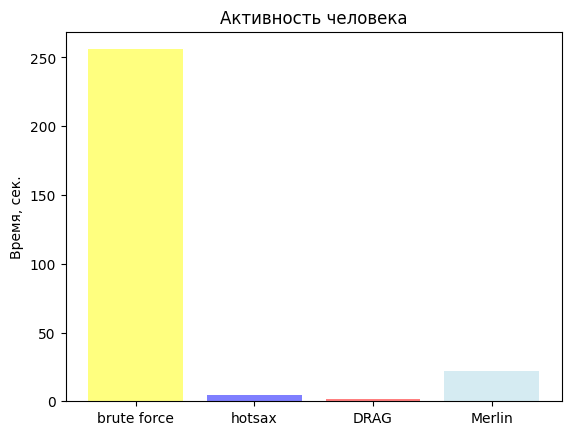

In [83]:
# @title
fig, ax = plt.subplots()
ax.set_title("Активность человека")
ax.bar(['brute force', 'hotsax', 'DRAG', 'Merlin'], [255.916, 4.699, 1.538, 21.660], color=['yellow', 'blue', 'red', 'lightblue'], alpha=0.5)
ax.set_ylabel('Время, сек.');

ТАКСИ (20 диссонансов)
*   Brute Force - время работы: 12602.030 сек Индексы: [3103 3205 1901 970 3864 3580 492 31 3315 140 2658 3755 3002 608 3465 2319 1074 2758 2136 269]
*   HotSax - время работы: 102.391 сек. Индексы: [3103 3205 1901 970 3864 3580 492 31 3315 140 2658 3755 3002 608 3465 2319 1074 2758 2136 269]
*   Merlin - время работы: 247.560 сек. Индексы: [1910 1952 3120 1934 3142 3183 3156 3237 3197 3280 3251 3102  963  991
 3915 1005 3295 3579  541 1840]

Все алгоритмы выявили схожие диссонансы, отклонения минимальны, что подтверждает стабильность и корректность результатов.

Алгоритмы Brute Force и HotSax дали полностью совпадающие индексы, что говорит о сохранении точности при значительном ускорении вычислений.

Время работы сократилось с 255.916 сек (Brute Force) до 4.699 сек (HotSax) и 0.538 сек (DRAG) - ускорение более чем в 500 раз при близкой точности.

Алгоритм Merlin также показал сопоставимые результаты (диссонансы, большая часть совпадений индексов), при умеренном времени в 21.660 сек, что делает его компромисным вариантом между точностью и скоростью

DRAG продемонстрировал наивысшую производительность (0.538 сек) при незначительной потере одного диссонанса, что делает его наиболее эффективным методом для больших потоков данных

Brute Force рекомендуется использовать как эталон для проверки качества других методов на ограниченных выборках

В практических сценариях анализа активности человека оптымиальным по соотношению точность/скорость являются HOT-SAX и DRAG